In [49]:
import pandas as pd

df = pd.read_csv('/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train.csv')

In [50]:
import os
from pathlib import Path
from IPython.display import display, HTML
from tqdm.auto import tqdm

# ── Config ─────────────────────────────────────────────────────────────────
LOCAL_DATA_ROOT      = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9"
SOURCE_CSV_PATH      = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train.csv"
SAVE_SUGGESTIONS_CSV = True   # write `suggested_folders_<csv>.csv` next to source CSV
# ───────────────────────────────────────────────────────────────────────────
 
# ─────────────────────────────────────────────────────────────────────────
# REPORT 1 — STRICT CHECK: does the literal CSV image_path exist on disk?
# ─────────────────────────────────────────────────────────────────────────
exist_image: list[str] = []
missing_image: list[str] = []
exist_labels: list = []
missing_labels: list = []
_has_labels = "labels" in df.columns

for i, img_path in enumerate(tqdm(df["image_path"].astype(str),
                                  desc="Strict is_file()", unit="row")):
    lbl = df["labels"].iat[i] if _has_labels else None
    if os.path.isfile(img_path):
        exist_image.append(img_path)
        exist_labels.append(lbl)
    else:
        missing_image.append(img_path)
        missing_labels.append(lbl)

print(f"\nStrict check (CSV path exists on disk):")
print(f"  ✓ Found:   {len(exist_image):,}")
print(f"  ✗ Missing: {len(missing_image):,}")

# 3) Per-folder coverage summary (depth=1 → first folder above the file)
def _src_folder(path_str, depth: int = 1) -> str:
    p = Path(str(path_str))
    for _ in range(depth):
        p = p.parent
    return p.name

def _folder_segments(path_str, n: int = 4) -> str:
    parts = Path(str(path_str)).parent.parts
    return "/".join(parts[-n:]) if len(parts) >= n else "/".join(parts)

found_df   = pd.DataFrame({"image_path": exist_image})
missing_df = pd.DataFrame({"image_path": missing_image})
found_df["source_folder"]   = found_df["image_path"].apply(_src_folder)
missing_df["source_folder"] = missing_df["image_path"].apply(_src_folder)

_all_df = pd.concat([found_df, missing_df], ignore_index=True)
_all_df["_seg4"] = _all_df["image_path"].apply(_folder_segments)
_seg4_map = _all_df.groupby("source_folder")["_seg4"].first().to_dict()

found_counts   = found_df.groupby("source_folder").size()
missing_counts = missing_df.groupby("source_folder").size()
all_folders    = sorted(set(found_counts.index) | set(missing_counts.index))

rows = []
for folder in all_folders:
    avail = int(found_counts.get(folder, 0))
    miss  = int(missing_counts.get(folder, 0))
    total = avail + miss
    pct   = 100.0 * avail / total if total else 0
    status = "✓" if miss == 0 else ("⚠" if pct > 50 else "✗")
    rows.append({
        "status": status, "source_folder": folder,
        "folder_path": _seg4_map.get(folder, ""),
        "total": total, "available": avail, "missing": miss,
        "coverage_pct": round(pct, 1),
    })
summary = pd.DataFrame(rows).sort_values("missing", ascending=False).reset_index(drop=True)

t_total = int(summary["total"].sum())
t_avail = int(summary["available"].sum())
t_miss  = int(summary["missing"].sum())
t_pct   = round(100.0 * t_avail / max(t_total, 1), 1)


def _bar(pct: float) -> str:
    color = "#27ae60" if pct == 100 else ("#f39c12" if pct > 50 else "#e74c3c")
    return (
        f'<div style="background:#eee;border-radius:4px;width:100%;height:16px">'
        f'<div style="background:{color};width:{pct}%;height:100%;border-radius:4px"></div>'
        f'</div>'
    )


def _status_badge(s: str) -> str:
    bg = {"✓": "#27ae60", "⚠": "#f39c12", "✗": "#e74c3c"}.get(s, "#999")
    return (
        f'<span style="background:{bg};color:#fff;padding:2px 8px;'
        f'border-radius:4px;font-weight:bold">{s}</span>'
    )

df.head()   
html_rows = ""
for _, r in summary.iterrows():
    html_rows += (
        f"<tr>"
        f"<td style='text-align:center'>{_status_badge(r['status'])}</td>"
        f"<td style='padding-left:8px'>{r['source_folder']}<br/>"
        f"<span style='font-size:10px;color:#555;max-width:260px;word-break:break-all'>"
        f"{r['folder_path']}</span></td>"
        f"<td style='text-align:right'>{r['total']:,}</td>"
        f"<td style='text-align:right;color:#27ae60'>{r['available']:,}</td>"
        f"<td style='text-align:right;color:#e74c3c'>{r['missing']:,}</td>"
        f"<td style='text-align:right'>{r['coverage_pct']} %</td>"
        f"<td style='min-width:120px'>{_bar(r['coverage_pct'])}</td>"
        f"</tr>"
    )

html_rows += (
    f"<tr style='border-top:2px solid #333;font-weight:bold;background:#f5f5f5'>"
    f"<td style='padding-left:8px'>TOTAL</td><td></td>"
    f"<td style='text-align:right'>{t_total:,}</td>"
    f"<td style='text-align:right;color:#27ae60'>{t_avail:,}</td>"
    f"<td style='text-align:right;color:#e74c3c'>{t_miss:,}</td>"
    f"<td style='text-align:right'>{t_pct} %</td>"
    f"<td>{_bar(t_pct)}</td>"
    f"</tr>"
)

html = f"""
<h3 style="margin-bottom:4px">REPORT 1 — Folder-wise Image Availability (strict CSV path check)</h3>
<table style="border-collapse:collapse;width:100%;font-size:13px;font-family:monospace">
<thead>
  <tr style="background:#2c3e50;color:#fff;text-align:left">
    <th style="padding:6px 8px;text-align:center">Status</th>
    <th style="padding:6px 8px;font-size:10px">Folder Path</th>
    <th style="padding:6px 8px;text-align:right">Total</th>
    <th style="padding:6px 8px;text-align:right">Available</th>
    <th style="padding:6px 8px;text-align:right">Missing</th>
    <th style="padding:6px 8px;text-align:right">Coverage</th>
    <th style="padding:6px 8px;min-width:120px"></th>
  </tr>
</thead>
<tbody>{html_rows}</tbody>
</table>
"""
display(HTML(html))

# ─────────────────────────────────────────────────────────────────────────
# REPORT 2 — SUGGESTIONS: for missing rows, locate the same basename
# anywhere under LOCAL_DATA_ROOT and propose an updated path.
# ─────────────────────────────────────────────────────────────────────────
local_root = Path(LOCAL_DATA_ROOT)
if not local_root.is_dir():
    raise FileNotFoundError(f"LOCAL_DATA_ROOT not found: {local_root}")

_img_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}
print(f"\nIndexing {local_root} for suggestions …")
local_index: dict[str, list[Path]] = {}
for dirpath, _, fnames in tqdm(os.walk(local_root),
                               desc="Indexing dirs", unit="dir"):
    for fname in fnames:
        if os.path.splitext(fname)[1].lower() in _img_exts:
            local_index.setdefault(fname, []).append(Path(dirpath) / fname)
print(f"  Indexed {sum(len(v) for v in local_index.values()):,} files "
      f"({len(local_index):,} unique basenames)")

from collections import Counter

per_row = []
for img_path, lbl in tqdm(zip(missing_image, missing_labels),
                          total=len(missing_image),
                          desc="Looking up", unit="row"):
    bname        = os.path.basename(img_path)
    csv_folder   = os.path.dirname(img_path)
    candidates   = local_index.get(bname, [])
    sugg_folders = [str(p.parent) for p in candidates]
    per_row.append({
        "csv_folder":         csv_folder,
        "labels":             lbl,
        "n_candidates":       len(candidates),
        "first_sugg_folder":  sugg_folders[0] if sugg_folders else "",
        "all_sugg_folders":   sugg_folders,
    })

per_row_df = pd.DataFrame(per_row)

folder_rows = []
for csv_folder, grp in per_row_df.groupby("csv_folder", sort=False):
    n_missing = len(grp)
    n_found   = int((grp["n_candidates"] > 0).sum())
    n_unres   = n_missing - n_found

    flat_folders = [f for lst in grp["all_sugg_folders"] for f in lst]
    folder_counts = Counter(flat_folders)
    top = folder_counts.most_common(3)
    top_folder = top[0][0] if top else ""
    top_share  = (100.0 * top[0][1] / n_missing) if top else 0.0
    other_top  = "; ".join(f"{f}({c})" for f, c in top[1:]) if len(top) > 1 else ""

    folder_rows.append({
        "csv_folder":          csv_folder,
        "n_missing":           n_missing,
        "n_found_alt":         n_found,
        "n_unresolved":        n_unres,
        "pct_found":           round(100.0 * n_found / max(n_missing, 1), 1),
        "pct_missing":         round(100.0 * n_unres / max(n_missing, 1), 1),
        "suggested_folder":    top_folder,
        "suggested_folder_share_pct": round(top_share, 1),
        "other_suggested_folders":    other_top,
    })

sugg_df = (pd.DataFrame(folder_rows)
             .sort_values(["pct_missing", "n_missing"], ascending=[False, False])
             .reset_index(drop=True))

n_folders        = len(sugg_df)
n_folder_resolved   = int((sugg_df["pct_found"] == 100.0).sum())
n_folder_partial    = int(((sugg_df["pct_found"] > 0) & (sugg_df["pct_found"] < 100)).sum())
n_folder_unresolved = int((sugg_df["pct_found"] == 0.0).sum())
tot_missing = int(sugg_df["n_missing"].sum())
tot_found   = int(sugg_df["n_found_alt"].sum())
tot_unres   = int(sugg_df["n_unresolved"].sum())

print(
    f"\nFolder-level suggestions  (across {n_folders:,} unique CSV folders):\n"
    f"  ✓ fully resolvable     : {n_folder_resolved:,}\n"
    f"  ⚠ partially resolvable : {n_folder_partial:,}\n"
    f"  ✗ unresolvable         : {n_folder_unresolved:,}\n"
    f"  Totals  →  missing rows: {tot_missing:,}   "
    f"found alt: {tot_found:,} ({100.0*tot_found/max(tot_missing,1):.1f}%)   "
    f"unresolved: {tot_unres:,} ({100.0*tot_unres/max(tot_missing,1):.1f}%)"
)

if SAVE_SUGGESTIONS_CSV and len(sugg_df):
    src_csv = Path(SOURCE_CSV_PATH)
    out_csv = src_csv.parent / f"suggested_folders_{src_csv.stem}.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    sugg_df.to_csv(out_csv, index=False)
    print(f"\n📥 Folder suggestions saved → {out_csv}  ({len(sugg_df):,} folders)")

# ── Render folder-level suggestions table ────────────────────────────────
def _pct_bar(pct: float, color: str) -> str:
    return (
        f'<div style="background:#eee;border-radius:4px;width:100%;height:14px">'
        f'<div style="background:{color};width:{pct}%;height:100%;border-radius:4px"></div>'
        f'</div>'
    )

def _row_status(pct_found: float) -> tuple[str, str]:
    if pct_found == 100.0: return ("✓", "#27ae60")
    if pct_found == 0.0:   return ("✗", "#e74c3c")
    return ("⚠", "#f39c12")

sugg_html_rows = ""
for _, r in sugg_df.iterrows():
    sym, sym_bg = _row_status(r["pct_found"])
    sugg = r["suggested_folder"] or '<em style="color:#999">no match</em>'
    extra = (f'<br/><span style="font-size:10px;color:#888">also: {r["other_suggested_folders"]}</span>'
             if r["other_suggested_folders"] else "")
    sugg_html_rows += (
        "<tr style='border-bottom:1px solid #eee'>"
        f"<td style='text-align:center;padding:4px 6px'>"
        f'<span style="background:{sym_bg};color:#fff;padding:2px 8px;'
        f'border-radius:4px;font-weight:bold">{sym}</span></td>'
        f"<td style='padding:4px 6px;font-size:11px;word-break:break-all;max-width:340px'>"
        f"<code style='color:#444'>{r['csv_folder']}</code></td>"
        f"<td style='padding:4px 6px;font-size:11px;word-break:break-all;max-width:340px'>"
        f"<code style='color:#27ae60'>{sugg}</code>"
        f"<span style='font-size:10px;color:#888'>"
        f" &nbsp;({r['suggested_folder_share_pct']:.1f}% of basenames)</span>{extra}</td>"
        f"<td style='text-align:right;padding:4px 6px'>{int(r['n_missing']):,}</td>"
        f"<td style='text-align:right;padding:4px 6px;color:#27ae60'>"
        f"{int(r['n_found_alt']):,} ({r['pct_found']:.1f}%)</td>"
        f"<td style='text-align:right;padding:4px 6px;color:#e74c3c'>"
        f"{int(r['n_unresolved']):,} ({r['pct_missing']:.1f}%)</td>"
        f"<td style='padding:4px 6px;min-width:140px'>"
        f"{_pct_bar(r['pct_found'], '#27ae60')}"
        f"{_pct_bar(r['pct_missing'], '#e74c3c')}</td>"
        "</tr>"
    )

# TOTAL row
tot_pct_found   = round(100.0 * tot_found / max(tot_missing, 1), 1)
tot_pct_missing = round(100.0 * tot_unres / max(tot_missing, 1), 1)
sugg_html_rows += (
    "<tr style='border-top:2px solid #333;font-weight:bold;background:#f5f5f5'>"
    "<td style='text-align:center;padding:6px'>Σ</td>"
    f"<td style='padding:6px'>TOTAL ({n_folders:,} folders)</td>"
    "<td></td>"
    f"<td style='text-align:right;padding:6px'>{tot_missing:,}</td>"
    f"<td style='text-align:right;padding:6px;color:#27ae60'>{tot_found:,} ({tot_pct_found:.1f}%)</td>"
    f"<td style='text-align:right;padding:6px;color:#e74c3c'>{tot_unres:,} ({tot_pct_missing:.1f}%)</td>"
    f"<td style='padding:6px'>{_pct_bar(tot_pct_found, '#27ae60')}"
    f"{_pct_bar(tot_pct_missing, '#e74c3c')}</td>"
    "</tr>"
)

sugg_html = f"""
<h3 style="margin:14px 0 4px 0">REPORT 2 — Folder-level Path Suggestions</h3>
<p style="font-size:12px;color:#444;margin:0 0 6px 0">
  One row per <b>unique CSV folder</b> with missing files.
  &nbsp;&nbsp;<span style="color:#27ae60">✓ fully resolvable: {n_folder_resolved:,}</span>
  &nbsp;&nbsp;<span style="color:#f39c12">⚠ partial: {n_folder_partial:,}</span>
  &nbsp;&nbsp;<span style="color:#e74c3c">✗ none found: {n_folder_unresolved:,}</span>
</p>
<div style="max-height:520px;overflow:auto;border:1px solid #ccc;border-radius:6px">
<table style="border-collapse:collapse;width:100%;font-family:monospace;font-size:12px">
<thead>
  <tr style="background:#34495e;color:#fff;text-align:left;position:sticky;top:0">
    <th style="padding:6px 8px;text-align:center">Status</th>
    <th style="padding:6px 8px">CSV folder (current)</th>
    <th style="padding:6px 8px">Suggested local folder (please update CSV)</th>
    <th style="padding:6px 8px;text-align:right">Missing</th>
    <th style="padding:6px 8px;text-align:right">Found alt</th>
    <th style="padding:6px 8px;text-align:right">Unresolved</th>
    <th style="padding:6px 8px;min-width:140px">Found / Missing %</th>
  </tr>
</thead>
<tbody>{sugg_html_rows}</tbody>
</table>
</div>
"""
display(HTML(sugg_html))


Strict is_file(): 100%|██████████| 704779/704779 [00:38<00:00, 18152.31row/s]



Strict check (CSV path exists on disk):
  ✓ Found:   573,542
  ✗ Missing: 131,237


Status,Folder Path,Total,Available,Missing,Coverage,
✗,realv9/gen_ai_detector_dataset/Shutterstock_Real/real,"68,588",0,"68,588",0.0 %,
✗,fake gen_ai_detector_dataset/PubDB_Fake/tristanzhang32_Fake/fake,"8,427",0,"8,427",0.0 %,
✗,real_faces_mtv_imagesgen_ai_detector_dataset/real_faces_multinational_130325/real/real_faces_mtv_images,"7,028",0,"7,028",0.0 %,
✗,INPUT_IMAGESmit_adobe_5k_Real/real/testing/INPUT_IMAGES,"6,672",0,"6,672",0.0 %,
✗,real_images_faces_and_othersgen_ai_detector_dataset/real_faces_multinational_130325/real/real_images_faces_and_others,"4,191",0,"4,191",0.0 %,
✗,Gen_samples_Grok2_200325v9/Gen_samples/fake/Gen_samples_Grok2_200325,"4,008",0,"4,008",0.0 %,
✗,code_gen_100325Gen_samples/fake/Gen_samples_Gemini_100325/code_gen_100325,"3,914",0,"3,914",0.0 %,
⚠,fakegen_ai_detector_dataset/PubDB_Fake/Shutterstock_Fake/fake,"38,490","35,345","3,145",91.8 %,
✗,Gen_samples_Gemini_190325v9/Gen_samples/fake/Gen_samples_Gemini_190325,"3,087",0,"3,087",0.0 %,
✗,Gen_samples_Gemini_150325v9/Gen_samples/fake/Gen_samples_Gemini_150325,"2,718",0,"2,718",0.0 %,



Indexing /home/taiaburrahman/dataset_manager_pro/data/processed/v9 for suggestions …


Indexing dirs: 157dir [00:23,  6.65dir/s]


  Indexed 913,409 files (881,813 unique basenames)


Looking up: 100%|██████████| 131237/131237 [00:01<00:00, 117966.99row/s]



Folder-level suggestions  (across 79 unique CSV folders):
  ✓ fully resolvable     : 78
  ⚠ partially resolvable : 0
  ✗ unresolvable         : 1
  Totals  →  missing rows: 131,237   found alt: 130,835 (99.7%)   unresolved: 402 (0.3%)

📥 Folder suggestions saved → /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/suggested_folders_GAID_Dataset_v9_full_Train.csv  (79 folders)


Status,CSV folder (current),Suggested local folder (please update CSV),Missing,Found alt,Unresolved,Found / Missing %
✗,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/Gen_samples/fake/Gen_samples_Gemini_100325/humangen_nature_070325,no match (0.0% of basenames),402,0 (0.0%),402 (100.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/ulid25k/real,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Real/ulid25k/real (100.0% of basenames),"24,200","24,200 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/Shutterstock_Real/real,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Real/home/ubuntu/vision/data/deepfake/Real_Images_to_Include/Shutterstock_Real/real (100.0% of basenames),"22,953","22,953 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/tristanzhang32_Real/real,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Real/tristanzhang32_Real/real (100.0% of basenames)also: /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Fake/tristanzhang32_Fake/fake(3549); /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Real/pht30k_Real/real(1716),"13,935","13,935 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Fake/tristanzhang32_Fake/fake,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Fake/tristanzhang32_Fake/fake (100.0% of basenames)also: /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Real/tristanzhang32_Real/real(3538); /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Fake/dalle_rec_Fake/fake(1284),"8,427","8,427 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/real_faces_multinational_130325/real/real_faces_mtv_images,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/real_faces_multinational_130325/real_faces_mtv_images (100.0% of basenames),"7,028","7,028 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/mit_adobe_5k_Real/real/training/INPUT_IMAGES,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/PubDB_Real/mit_adobe_5k_Real/real/training/INPUT_IMAGES (100.0% of basenames),"4,766","4,766 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/real_faces_multinational_130325/real/real_images_faces_and_others,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/real_faces_multinational_130325/real_images_faces_and_others (100.0% of basenames),"4,191","4,191 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/Gen_samples/fake/Gen_samples_Grok2_200325,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human (91.0% of basenames)also: /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human_2(355); /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human_3(11),"4,008","4,008 (100.0%)",0 (0.0%),
✓,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/Gen_samples/fake/Gen_samples_Gemini_100325/code_gen_100325,/home/taiaburrahman/dataset_manager_pro/data/processed/v9/Gen_samples/fake/Gen_samples_Gemini_100325 (100.0% of basenames)also: /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human(3736); /home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human_2(168),"3,914","3,914 (100.0%)",0 (0.0%),


In [51]:
# ─────────────────────────────────────────────────────────────────────────
# REPORT 3 — AUTO-CORRECT image_path in the CSV using the suggestions
#   - For every missing row that has at least one candidate basename match
#     under LOCAL_DATA_ROOT, replace its image_path with the FIRST suggested
#     folder + original basename.
#   - Rows still missing or unresolved keep their original path.
#   - Writes <stem>_autocorrected.csv next to the source CSV (non-destructive).
# Requires variables produced by the previous cell:
#   df, missing_image, per_row, SOURCE_CSV_PATH
# ─────────────────────────────────────────────────────────────────────────
OVERWRITE_SOURCE_CSV = False   # set True to overwrite SOURCE_CSV_PATH in place

src_csv = Path(SOURCE_CSV_PATH)

correction_map: dict[str, str] = {}
for orig_path, info in zip(missing_image, per_row):
    sugg_folder = info.get("first_sugg_folder", "")
    if sugg_folder:
        bname = os.path.basename(str(orig_path))
        correction_map[str(orig_path)] = os.path.join(sugg_folder, bname)

print(f"Auto-correct map built: {len(correction_map):,} paths will be rewritten "
      f"(out of {len(missing_image):,} missing).")

df_corrected = df.copy()
orig_paths = df_corrected["image_path"].astype(str)
df_corrected["image_path"] = orig_paths.map(lambda p: correction_map.get(p, p))

# Track which rows changed and verify on disk
changed_mask = df_corrected["image_path"].astype(str) != orig_paths
n_changed   = int(changed_mask.sum())

verify_paths = df_corrected.loc[changed_mask, "image_path"].astype(str).tolist()
n_changed_ok = sum(
    1 for p in tqdm(verify_paths, desc="Verifying corrected paths", unit="row")
    if os.path.isfile(p)
)
n_changed_bad = n_changed - n_changed_ok

all_paths = df_corrected["image_path"].astype(str).tolist()
n_total_found = sum(
    1 for p in tqdm(all_paths, desc="Final strict check", unit="row")
    if os.path.isfile(p)
)
n_total_missing = len(all_paths) - n_total_found

print(
    f"\nAuto-correction summary:\n"
    f"  rows changed                  : {n_changed:,}\n"
    f"  changed → exists on disk      : {n_changed_ok:,}\n"
    f"  changed → still missing       : {n_changed_bad:,}\n"
    f"  TOTAL existing after fix      : {n_total_found:,}\n"
    f"  TOTAL missing  after fix      : {n_total_missing:,}\n"
    f"  coverage after fix            : "
    f"{100.0 * n_total_found / max(len(all_paths), 1):.2f} %"
)

# Save
if OVERWRITE_SOURCE_CSV:
    out_csv = src_csv
else:
    out_csv = src_csv.parent / f"{src_csv.stem}_autocorrected.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_corrected.to_csv(out_csv, index=False)
print(f"\n📥 Auto-corrected CSV saved → {out_csv}  ({len(df_corrected):,} rows)")

Auto-correct map built: 130,835 paths will be rewritten (out of 131,237 missing).


Final strict check: 100%|██████████| 704779/704779 [00:02<00:00, 247025.48row/s]



Auto-correction summary:
  rows changed                  : 130,835
  changed → exists on disk      : 130,835
  changed → still missing       : 0
  TOTAL existing after fix      : 704,377
  TOTAL missing  after fix      : 402
  coverage after fix            : 99.94 %

📥 Auto-corrected CSV saved → /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected.csv  (704,779 rows)


In [52]:
# ─────────────────────────────────────────────────────────────────────────
# REPORT 4 — STANDALONE AUTO-CORRECT (folder-mapping based)
#   Uses the previously-saved `suggested_folders_<stem>.csv` to rewrite the
#   image_path column for ALL rows whose folder appears in the mapping.
#   Self-contained: only needs SOURCE_CSV_PATH and the suggestions CSV.
# ─────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

SOURCE_CSV_PATH = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train.csv"
OVERWRITE_SOURCE_CSV = False         # True → overwrite SOURCE_CSV_PATH in place
ONLY_REWRITE_IF_MISSING = True       # True → only rewrite rows whose CURRENT path doesn't exist

src_csv  = Path(SOURCE_CSV_PATH)
sugg_csv = src_csv.parent / f"suggested_folders_{src_csv.stem}.csv"
if not sugg_csv.is_file():
    raise FileNotFoundError(f"Suggestions CSV not found: {sugg_csv}\n"
                            f"Run REPORT 2 first to generate it.")

print(f"Source CSV       : {src_csv}")
print(f"Suggestions CSV  : {sugg_csv}")

df_src  = pd.read_csv(src_csv)
df_sugg = pd.read_csv(sugg_csv)

import re
_other_pat = re.compile(r"(?P<path>.+?)\((?P<n>\d+)\)\s*")

def _parse_other(s):
    if not isinstance(s, str) or not s.strip():
        return []
    out = []
    for chunk in s.split(";"):
        m = _other_pat.match(chunk.strip())
        if m:
            out.append((m.group("path").rstrip("/"), int(m.group("n"))))
    out.sort(key=lambda x: x[1], reverse=True)
    return [p for p, _ in out]

folder_map: dict[str, list[str]] = {}
for _, r in df_sugg.iterrows():
    csv_folder = str(r["csv_folder"]).rstrip("/")
    primary    = str(r.get("suggested_folder") or "").strip().rstrip("/")
    fallbacks  = _parse_other(r.get("other_suggested_folders"))
    candidates = ([primary] if primary else []) + [f for f in fallbacks if f and f != primary]
    if candidates:
        folder_map[csv_folder] = candidates
print(f"Folder mapping entries (with ≥1 candidate): {len(folder_map):,}")

orig_paths = df_src["image_path"].astype(str).tolist()
new_paths: list[str] = []
status: list[str] = []
n_changed = 0
n_primary = 0
n_fallback = 0
n_unmapped_missing = 0
n_mapped_unfixable = 0

for p in tqdm(orig_paths, desc="Rewriting paths", unit="row"):
    folder = os.path.dirname(p).rstrip("/")
    bname  = os.path.basename(p)
    if ONLY_REWRITE_IF_MISSING and os.path.isfile(p):
        new_paths.append(p); status.append("ok-original"); continue
    cands = folder_map.get(folder)
    if not cands:
        new_paths.append(p); status.append("missing-no-mapping")
        n_unmapped_missing += 1
        continue
    chosen = None
    chosen_rank = -1
    for i, d in enumerate(cands):
        cand_path = os.path.join(d, bname)
        if os.path.isfile(cand_path):
            chosen = cand_path; chosen_rank = i; break
    if chosen is None:
        chosen = os.path.join(cands[0], bname)
        new_paths.append(chosen); status.append("missing-after-rewrite")
        n_mapped_unfixable += 1
        if chosen != p: n_changed += 1
        continue
    if chosen != p: n_changed += 1
    if chosen_rank == 0: n_primary  += 1
    else:                n_fallback += 1
    new_paths.append(chosen)
    status.append("fixed-primary" if chosen_rank == 0 else f"fixed-fallback#{chosen_rank}")

df_out = df_src.copy()
df_out["image_path"]  = new_paths
df_out["path_status"] = status

# Verify the corrected paths
n_found_after = sum(
    1 for p in tqdm(new_paths, desc="Final strict check", unit="row")
    if os.path.isfile(p)
)
n_missing_after = len(new_paths) - n_found_after

print(
    f"\nRewrite summary:\n"
    f"  rows changed                       : {n_changed:,}\n"
    f"  fixed via primary suggestion       : {n_primary:,}\n"
    f"  fixed via fallback suggestion      : {n_fallback:,}\n"
    f"  mapped but no candidate exists     : {n_mapped_unfixable:,}\n"
    f"  rows missing & no folder mapping   : {n_unmapped_missing:,}\n"
    f"  TOTAL existing after fix           : {n_found_after:,}\n"
    f"  TOTAL missing  after fix           : {n_missing_after:,}\n"
    f"  coverage after fix                 : "
    f"{100.0 * n_found_after / max(len(new_paths), 1):.2f} %"
)

if OVERWRITE_SOURCE_CSV:
    out_csv = src_csv
else:
    out_csv = src_csv.parent / f"{src_csv.stem}_autocorrected_full.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(out_csv, index=False)
print(f"\n📥 Auto-corrected CSV saved → {out_csv}  ({len(df_out):,} rows)")


Source CSV       : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train.csv
Suggestions CSV  : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/suggested_folders_GAID_Dataset_v9_full_Train.csv
Folder mapping entries (with ≥1 candidate): 79


Final strict check: 100%|██████████| 704779/704779 [00:03<00:00, 215988.03row/s]



Rewrite summary:
  rows changed                       : 131,237
  fixed via primary suggestion       : 130,437
  fixed via fallback suggestion      : 398
  mapped but no candidate exists     : 402
  rows missing & no folder mapping   : 0
  TOTAL existing after fix           : 704,377
  TOTAL missing  after fix           : 402
  coverage after fix                 : 99.94 %

📥 Auto-corrected CSV saved → /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full.csv  (704,779 rows)


Loaded 704,779 rows from /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full.csv
Columns: ['image_path', 'labels', 'directory', 'path_status']


Disk check: 100%|██████████| 704779/704779 [00:05<00:00, 139757.61row/s]



── Label distribution ──
  fake (AI)         361,715  (51.32 %)
  real (human)      343,064  (48.68 %)

── Disk availability ──
  exists        704,377  (99.94 %)
  missing           402  ( 0.06 %)


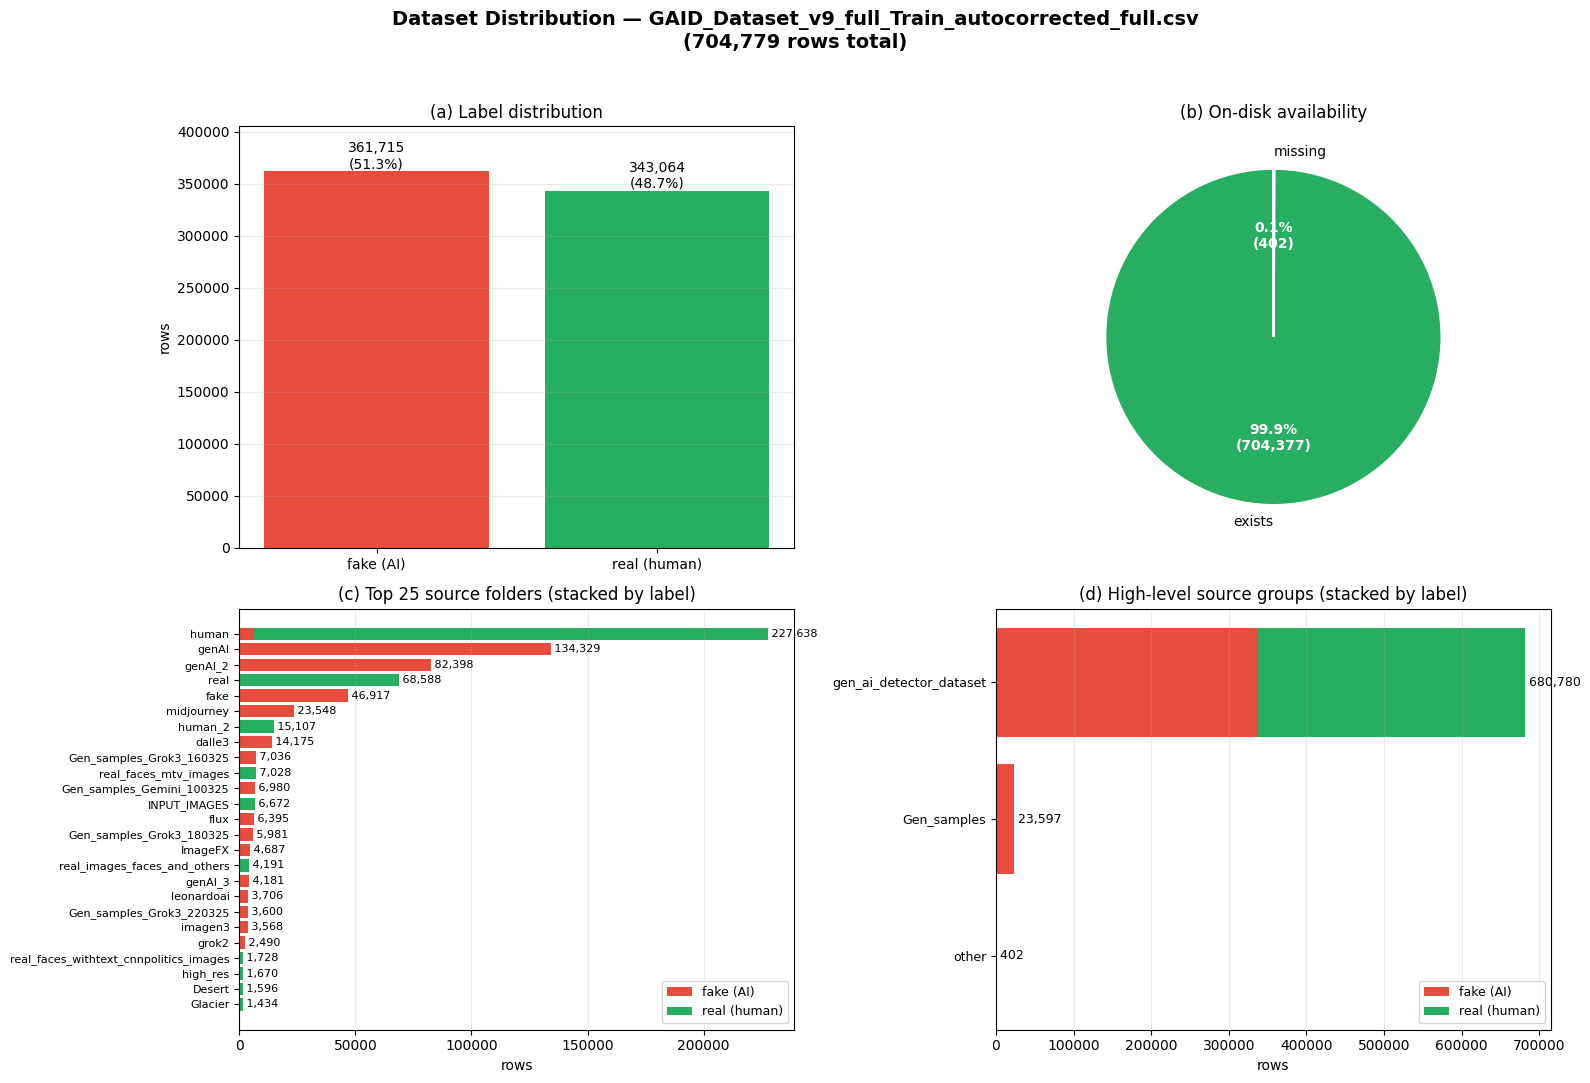


📊 Saved figure → /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full_distribution.png


In [53]:
# ─────────────────────────────────────────────────────────────────────────
# REPORT 5 — DATA DISTRIBUTION (auto-corrected CSV)
#   Visualizes:
#     (a) overall label distribution                  (real vs fake)
#     (b) on-disk availability                        (exists vs missing)
#     (c) top-N source folders by row count           (stacked by label)
#     (d) parent-source-folder distribution           (top-level grouping)
# ─────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

CSV_PATH = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full.csv"
TOP_N    = 25       # top folders to show
DO_DISK_CHECK = True

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows from {CSV_PATH}")
print(f"Columns: {list(df.columns)}")

LABEL_NAMES = {0: "fake (AI)", 1: "real (human)"}
df["label_name"]    = df["labels"].map(LABEL_NAMES).fillna(df["labels"].astype(str))
df["source_folder"] = df["image_path"].astype(str).map(lambda p: Path(p).parent.name)
df["top_group"]     = df["image_path"].astype(str).map(
    lambda p: next((part for part in Path(p).parts
                    if part in {"PubDB_Real", "PubDB_Fake", "Gen_samples",
                                "gen_ai_detector_dataset", "ai_image_x_collection_feb25_cleaned",
                                "real_faces_multinational_130325"}), "other")
)

if DO_DISK_CHECK:
    df["exists"] = [
        os.path.isfile(p) for p in tqdm(df["image_path"].astype(str),
                                        desc="Disk check", unit="row")
    ]
else:
    df["exists"] = True

label_counts = df["label_name"].value_counts().sort_index()
exists_counts = df["exists"].value_counts().rename({True: "exists", False: "missing"})

print("\n── Label distribution ──")
for k, v in label_counts.items():
    print(f"  {k:<14s} {v:>10,}  ({100.0*v/len(df):5.2f} %)")

print("\n── Disk availability ──")
for k, v in exists_counts.items():
    print(f"  {k:<10s} {v:>10,}  ({100.0*v/len(df):5.2f} %)")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f"Dataset Distribution — {Path(CSV_PATH).name}\n"
             f"({len(df):,} rows total)", fontsize=14, fontweight="bold")

ax = axes[0, 0]
colors_lbl = ["#e74c3c", "#27ae60"]
bars = ax.bar(label_counts.index, label_counts.values, color=colors_lbl[:len(label_counts)])
ax.set_title("(a) Label distribution", fontsize=12)
ax.set_ylabel("rows")
for b, v in zip(bars, label_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({100.0*v/len(df):.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, max(label_counts.values) * 1.12)
ax.grid(axis="y", alpha=0.25)

ax = axes[0, 1]
exists_order = ["exists", "missing"]
exists_vals  = [int(exists_counts.get(k, 0)) for k in exists_order]
colors_ex    = ["#27ae60", "#e74c3c"]
wedges, _, autotexts = ax.pie(
    exists_vals, labels=exists_order, colors=colors_ex,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p*sum(exists_vals)/100)):,})",
    startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2),
)
for t in autotexts:
    t.set_color("white"); t.set_fontweight("bold")
ax.set_title("(b) On-disk availability", fontsize=12)

ax = axes[1, 0]
top_folders = (df.groupby("source_folder").size()
                 .sort_values(ascending=False).head(TOP_N).index.tolist())
sub = df[df["source_folder"].isin(top_folders)]
pivot = (sub.pivot_table(index="source_folder", columns="label_name",
                         values="image_path", aggfunc="count", fill_value=0)
            .reindex(top_folders))
pivot = pivot[[c for c in ["fake (AI)", "real (human)"] if c in pivot.columns]]
y = np.arange(len(pivot))
left = np.zeros(len(pivot))
for i, col in enumerate(pivot.columns):
    vals = pivot[col].values
    ax.barh(y, vals, left=left, label=col, color=colors_lbl[i])
    left += vals
ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("rows")
ax.set_title(f"(c) Top {TOP_N} source folders (stacked by label)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.25)
for i, total in enumerate(pivot.sum(axis=1).values):
    ax.text(total, i, f" {int(total):,}", va="center", fontsize=8)

ax = axes[1, 1]
group_counts = (df.pivot_table(index="top_group", columns="label_name",
                               values="image_path", aggfunc="count", fill_value=0)
                  .sort_values(by=df["label_name"].unique().tolist()[0]
                                if len(df["label_name"].unique()) else "fake (AI)",
                               ascending=True, ignore_index=False))
group_counts = group_counts.reindex(group_counts.sum(axis=1).sort_values().index)
group_counts = group_counts[[c for c in ["fake (AI)", "real (human)"] if c in group_counts.columns]]
y = np.arange(len(group_counts))
left = np.zeros(len(group_counts))
for i, col in enumerate(group_counts.columns):
    vals = group_counts[col].values
    ax.barh(y, vals, left=left, label=col, color=colors_lbl[i])
    left += vals
ax.set_yticks(y); ax.set_yticklabels(group_counts.index, fontsize=9)
ax.set_xlabel("rows")
ax.set_title("(d) High-level source groups (stacked by label)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.25)
for i, total in enumerate(group_counts.sum(axis=1).values):
    ax.text(total, i, f" {int(total):,}", va="center", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
out_png = Path(CSV_PATH).with_suffix("").as_posix() + "_distribution.png"
plt.savefig(out_png, dpi=130, bbox_inches="tight")
plt.show()
print(f"\n📊 Saved figure → {out_png}")


In [54]:
# ─────────────────────────────────────────────────────────────────────────
# REPORT 6 — EXTRA FILES ON DISK NOT REFERENCED BY THE CSV
#   Walks LOCAL_DATA_ROOT, collects every image file, then subtracts the
#   set of image_path values referenced in the (auto-corrected) CSV.
#   Reports total count + per-folder breakdown.
# ─────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import display, HTML

LOCAL_DATA_ROOT       = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9"
CSV_PATH              = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full.csv"
SAVE_EXTRAS_LIST_CSV  = True   # save full per-file list as extras_<stem>.csv next to CSV
SAVE_EXTRAS_PER_FOLDER_CSV = True
TOP_N_FOLDERS         = 50

_img_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}

local_root = Path(LOCAL_DATA_ROOT)
if not local_root.is_dir():
    raise FileNotFoundError(f"LOCAL_DATA_ROOT not found: {local_root}")

print(f"Indexing {local_root} for all image files …")
all_local: set[str] = set()
for dirpath, _, fnames in tqdm(os.walk(local_root), desc="Indexing dirs", unit="dir"):
    for fname in fnames:
        if os.path.splitext(fname)[1].lower() in _img_exts:
            all_local.add(os.path.join(dirpath, fname))
print(f"  Total image files on disk under LOCAL_DATA_ROOT : {len(all_local):,}")

print(f"\nLoading CSV {CSV_PATH} …")
df_csv = pd.read_csv(CSV_PATH, usecols=["image_path"])
csv_paths: set[str] = set(df_csv["image_path"].astype(str).tolist())
print(f"  Unique image_path entries in CSV               : {len(csv_paths):,}")

extra_paths = sorted(all_local - csv_paths)
print(f"\n→ Extra files on disk not referenced by the CSV : {len(extra_paths):,}")

if not extra_paths:
    print("✓ Nothing to report. Every file under LOCAL_DATA_ROOT is referenced by the CSV.")
else:
    extras_df = pd.DataFrame({"path": extra_paths})
    extras_df["folder"] = extras_df["path"].map(lambda p: os.path.dirname(p))
    folder_counts = (extras_df.groupby("folder").size()
                     .sort_values(ascending=False)
                     .reset_index(name="extra_files"))
    folder_counts["pct_of_extras"] = (
        100.0 * folder_counts["extra_files"] / max(len(extras_df), 1)
    ).round(2)

    n_folders = len(folder_counts)
    print(f"  Folders containing extras                       : {n_folders:,}")

    src_csv = Path(CSV_PATH)
    if SAVE_EXTRAS_LIST_CSV:
        out_list = src_csv.parent / f"extras_{src_csv.stem}.csv"
        extras_df.to_csv(out_list, index=False)
        print(f"  📥 Per-file list saved   → {out_list}  ({len(extras_df):,} rows)")
    if SAVE_EXTRAS_PER_FOLDER_CSV:
        out_folder = src_csv.parent / f"extras_per_folder_{src_csv.stem}.csv"
        folder_counts.to_csv(out_folder, index=False)
        print(f"  📥 Per-folder list saved → {out_folder}  ({n_folders:,} folders)")

    top = folder_counts.head(TOP_N_FOLDERS)
    rows_html = ""
    for _, r in top.iterrows():
        rows_html += (
            "<tr style='border-bottom:1px solid #eee'>"
            f"<td style='padding:4px 8px;font-size:11px;word-break:break-all;max-width:600px'>"
            f"<code style='color:#fff'>{r['folder']}</code></td>"
            f"<td style='text-align:right;padding:4px 8px;color:#e67e22'>{int(r['extra_files']):,}</td>"
            f"<td style='text-align:right;padding:4px 8px;color:#888'>{r['pct_of_extras']:.2f}%</td>"
            "</tr>"
        )
    rows_html += (
        "<tr style='border-top:2px solid #333;font-weight:bold;background:#f5f5f5'>"
        f"<td style='padding:6px 8px'>TOTAL ({n_folders:,} folders)</td>"
        f"<td style='text-align:right;padding:6px 8px'>{len(extras_df):,}</td>"
        f"<td style='text-align:right;padding:6px 8px'>100.00%</td>"
        "</tr>"
    )
    html = f"""
    <h3 style="margin:14px 0 4px 0">REPORT 6 — Extra files on disk not referenced by the CSV</h3>
    <p style="font-size:12px;color:#444;margin:0 0 6px 0">
      Disk root: <code>{local_root}</code> &nbsp;·&nbsp;
      CSV: <code>{src_csv.name}</code> &nbsp;·&nbsp;
      Extras: <b style="color:#e67e22">{len(extras_df):,}</b> across
      <b>{n_folders:,}</b> folders &nbsp;(showing top {min(TOP_N_FOLDERS, n_folders)})
    </p>
    <div style="max-height:520px;overflow:auto;border:1px solid #ccc;border-radius:6px">
    <table style="border-collapse:collapse;width:100%;font-family:monospace;font-size:12px">
    <thead>
      <tr style="background:#34495e;color:#fff;text-align:left;position:sticky;top:0">
        <th style="padding:6px 8px">Folder</th>
        <th style="padding:6px 8px;text-align:right">Extra files</th>
        <th style="padding:6px 8px;text-align:right">% of extras</th>
      </tr>
    </thead>
    <tbody>{rows_html}</tbody>
    </table>
    </div>
    """
    display(HTML(html))


Indexing /home/taiaburrahman/dataset_manager_pro/data/processed/v9 for all image files …


Indexing dirs: 0dir [00:00, ?dir/s]

Indexing dirs: 157dir [00:02, 56.47dir/s] 


  Total image files on disk under LOCAL_DATA_ROOT : 913,409

Loading CSV /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full.csv …
  Unique image_path entries in CSV               : 694,260

→ Extra files on disk not referenced by the CSV : 219,551
  Folders containing extras                       : 99
  📥 Per-file list saved   → /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/extras_GAID_Dataset_v9_full_Train_autocorrected_full.csv  (219,551 rows)
  📥 Per-folder list saved → /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/extras_per_folder_GAID_Dataset_v9_full_Train_autocorrected_full.csv  (99 folders)


Folder,Extra files,% of extras
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human,"114,736",52.26%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/genAI,"35,743",16.28%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/genAI_2,"21,626",9.85%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/Gen_samples_Grok3_180325/Gen_samples_Grok3_180325,"12,356",5.63%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/testset/testset_1,"6,846",3.12%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/Gen_samples/fake/Gen_samples_Grok3_180325,"6,375",2.90%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human_2,"4,091",1.86%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/Gen_samples/fake/Gen_samples_Grok3_220325,"3,834",1.75%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/ai_image_x_collection_feb25_cleaned/midjourney,"2,608",1.19%
/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/ai_image_x_collection_feb25_cleaned/dalle3,"1,570",0.72%


In [55]:
# ─────────────────────────────────────────────────────────────────────────
# REPORT 7 — RELOCATE FILES TO A NEW ROOT + EMIT REWRITTEN CSV
#   Reads a (verified) CSV, copies / moves / symlinks every referenced image
#   into a new directory layout, and writes a new CSV whose `image_path`
#   column points at the new location.
# ─────────────────────────────────────────────────────────────────────────
import os
import shutil
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

CSV_PATH      = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full.csv"
NEW_ROOT      = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/02.processing/v9_relocated"

MODE          = "copy"          # "copy" | "move" | "symlink"
STRATEGY      = "mirror"        # "mirror" preserves the existing folder structure under NEW_ROOT
                                # other options: "by_label" | "by_source_folder" | "flat"

OLD_ROOT      = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9"   # used by STRATEGY="mirror" to compute relative paths
LABEL_DIRS    = {0: "fake", 1: "real"}                                        # only used by STRATEGY="by_label"

OVERWRITE     = False           # True → overwrite if destination already exists
DRY_RUN       = False           # True → plan only, no filesystem changes
SKIP_MISSING  = True            # True → silently skip rows whose source file is missing

assert MODE in {"copy", "move", "symlink"}
assert STRATEGY in {"by_label", "by_source_folder", "mirror", "flat"}

src_csv  = Path(CSV_PATH)
new_root = Path(NEW_ROOT)
print(f"Source CSV : {src_csv}")
print(f"New root   : {new_root}")
print(f"Mode       : {MODE}     Strategy: {STRATEGY}     Dry-run: {DRY_RUN}")

df_in = pd.read_csv(src_csv)
required_cols = {"image_path"}
if STRATEGY == "by_label":
    required_cols.add("labels")
missing_cols = required_cols - set(df_in.columns)
if missing_cols:
    raise ValueError(f"CSV is missing required columns for STRATEGY={STRATEGY!r}: {missing_cols}")
print(f"Loaded {len(df_in):,} rows.")

def _dest_for(row) -> Path:
    src = Path(str(row["image_path"]))
    bname = src.name
    if STRATEGY == "flat":
        return new_root / bname
    if STRATEGY == "by_label":
        sub = LABEL_DIRS.get(row["labels"], str(row["labels"]))
        return new_root / sub / bname
    if STRATEGY == "by_source_folder":
        return new_root / src.parent.name / bname
    if str(src).startswith(OLD_ROOT):
        rel = os.path.relpath(src, OLD_ROOT)
    else:
        rel = str(src).lstrip(os.sep)
    return new_root / rel

def _resolve_collision(dest: Path, src: Path) -> Path:
    if not dest.exists():
        return dest
    if OVERWRITE:
        return dest
    try:
        if dest.resolve() == src.resolve():
            return dest
    except Exception:
        pass
    if dest.is_file() and src.is_file() and dest.stat().st_size == src.stat().st_size:
        return dest
    stem, suf = dest.stem, dest.suffix
    parent   = dest.parent
    i = 1
    while True:
        cand = parent / f"{stem}_{i}{suf}"
        if not cand.exists():
            return cand
        i += 1

def _do_action(src: Path, dest: Path) -> None:
    if DRY_RUN:
        return
    dest.parent.mkdir(parents=True, exist_ok=True)
    if MODE == "copy":
        if dest.exists() and OVERWRITE:
            dest.unlink()
        shutil.copy2(src, dest)
    elif MODE == "move":
        if dest.exists() and OVERWRITE:
            dest.unlink()
        shutil.move(str(src), str(dest))
    else:  # symlink
        if dest.exists() and OVERWRITE:
            dest.unlink()
        os.symlink(os.path.abspath(src), dest)

new_paths: list[str] = []
status: list[str]    = []
n_done    = 0
n_skipped_missing = 0
n_already = 0
n_collision_renamed = 0
n_failed  = 0
errors    = []

for _, row in tqdm(df_in.iterrows(), total=len(df_in),
                    desc=f"{MODE.title()}ing files", unit="file"):
    src = Path(str(row["image_path"]))
    if not src.is_file():
        if SKIP_MISSING:
            new_paths.append(str(src))
            status.append("source-missing")
            n_skipped_missing += 1
            continue
        else:
            errors.append(f"missing: {src}")
            n_failed += 1
            new_paths.append(str(src))
            status.append("source-missing-error")
            continue

    dest = _dest_for(row)
    final = _resolve_collision(dest, src)
    if final != dest:
        n_collision_renamed += 1

    try:
        if final.exists() and not OVERWRITE and final.resolve() == src.resolve():
            status.append("already-at-destination")
            n_already += 1
        elif final.exists() and not OVERWRITE and final != dest:
            status.append("collision-renamed")
            _do_action(src, final)
            n_done += 1
        else:
            _do_action(src, final)
            status.append(f"{MODE}-ok")
            n_done += 1
    except Exception as e:
        n_failed += 1
        errors.append(f"{src} → {final}: {e}")
        status.append(f"{MODE}-failed")

    new_paths.append(str(final))

df_out = df_in.copy()
df_out["image_path"]    = new_paths
df_out["relocate_status"] = status

print(
    f"\nRelocation summary ({MODE}, strategy={STRATEGY}{', dry-run' if DRY_RUN else ''}):\n"
    f"  done                     : {n_done:,}\n"
    f"  already at destination   : {n_already:,}\n"
    f"  collision-renamed        : {n_collision_renamed:,}\n"
    f"  source-missing skipped   : {n_skipped_missing:,}\n"
    f"  failed                   : {n_failed:,}\n"
)
if errors[:5]:
    print("First few errors:")
    for e in errors[:5]:
        print(f"  ! {e}")
    if len(errors) > 5:
        print(f"  …and {len(errors) - 5} more.")

stem = src_csv.stem
suffix = "_dryrun" if DRY_RUN else f"_relocated_{STRATEGY}"
out_csv = src_csv.parent / f"{stem}{suffix}.csv"
df_out.to_csv(out_csv, index=False)
print(f"\n📥 New CSV with relocated paths saved → {out_csv}  ({len(df_out):,} rows)")

if not DRY_RUN:
    sample = df_out.head(3)["image_path"].tolist()
    sample_ok = sum(1 for p in sample if os.path.isfile(p))
    print(f"  Quick sanity check on first 3 rows: {sample_ok}/3 exist on disk.")


Source CSV : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full.csv
New root   : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/02.processing/v9_relocated
Mode       : copy     Strategy: mirror     Dry-run: False
Loaded 704,779 rows.


Copying files: 100%|██████████| 704779/704779 [30:07<00:00, 389.82file/s]  



Relocation summary (copy, strategy=mirror):
  done                     : 704,377
  already at destination   : 0
  collision-renamed        : 86,230
  source-missing skipped   : 402
  failed                   : 0


📥 New CSV with relocated paths saved → /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected_full_relocated_mirror.csv  (704,779 rows)
  Quick sanity check on first 3 rows: 3/3 exist on disk.


In [59]:
# REPORT 8 - RELOCATE *EXTRA* FILES (on disk but NOT in CSV) TO A NEW ROOT
#   Indexes LOCAL_DATA_ROOT, subtracts the set of image_path values referenced
#   in the (auto-corrected) CSV, then copies/moves every "extra" file to
#   EXTRAS_NEW_ROOT while preserving the original folder structure.
#   Emits a manifest CSV listing each extra with its old + new path.

import os
import shutil
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

LOCAL_DATA_ROOT  = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9"
CSV_PATH         = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected.csv"
EXTRAS_NEW_ROOT  = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9_extras"

MODE             = "move"
OVERWRITE        = False
DRY_RUN          = False
SAVE_EXTRAS_CSV  = True

assert MODE in {"copy", "move", "symlink"}

_img_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}

local_root = Path(LOCAL_DATA_ROOT)
new_root   = Path(EXTRAS_NEW_ROOT)
src_csv    = Path(CSV_PATH)
print(f"Disk root  : {local_root}")
print(f"Source CSV : {src_csv}")
print(f"New root   : {new_root}")
print(f"Mode       : {MODE}     Dry-run: {DRY_RUN}")

if not local_root.is_dir():
    raise FileNotFoundError(f"LOCAL_DATA_ROOT not found: {local_root}")

print(f"\nIndexing {local_root} for all image files ...")
all_local: set[str] = set()
for dirpath, _, fnames in tqdm(os.walk(local_root), desc="Indexing dirs", unit="dir"):
    for fname in fnames:
        if os.path.splitext(fname)[1].lower() in _img_exts:
            all_local.add(os.path.join(dirpath, fname))
print(f"  Total image files on disk : {len(all_local):,}")

print(f"\nLoading CSV {src_csv.name} ...")
df_csv = pd.read_csv(src_csv, usecols=["image_path"])
csv_paths: set[str] = set(df_csv["image_path"].astype(str).tolist())
print(f"  CSV image_path entries    : {len(csv_paths):,}")

extra_paths = sorted(all_local - csv_paths)
print(f"\nExtra files on disk not in CSV : {len(extra_paths):,}")

if not extra_paths:
    print("Nothing to relocate - every disk file is referenced by the CSV.")
else:
    def _dest_for(src: Path) -> Path:
        s = str(src)
        if s.startswith(str(local_root)):
            rel = os.path.relpath(s, str(local_root))
        else:
            rel = s.lstrip(os.sep)
        return new_root / rel

    def _resolve_collision(dest: Path, src: Path) -> Path:
        if not dest.exists() or OVERWRITE:
            return dest
        try:
            if dest.resolve() == src.resolve():
                return dest
        except Exception:
            pass
        if dest.is_file() and src.is_file() and dest.stat().st_size == src.stat().st_size:
            return dest
        stem, suf = dest.stem, dest.suffix
        i = 1
        while True:
            cand = dest.parent / f"{stem}_{i}{suf}"
            if not cand.exists():
                return cand
            i += 1

    def _do_action(src: Path, dest: Path) -> None:
        if DRY_RUN:
            return
        dest.parent.mkdir(parents=True, exist_ok=True)
        if MODE == "copy":
            if dest.exists() and OVERWRITE:
                dest.unlink()
            shutil.copy2(src, dest)
        elif MODE == "move":
            if dest.exists() and OVERWRITE:
                dest.unlink()
            shutil.move(str(src), str(dest))
        else:
            if dest.exists() and OVERWRITE:
                dest.unlink()
            os.symlink(os.path.abspath(src), dest)

    rows: list[dict] = []
    n_done = 0
    n_already = 0
    n_collision_renamed = 0
    n_failed = 0
    errors: list[str] = []

    for p in tqdm(extra_paths, desc=f"{MODE.title()}ing extras", unit="file"):
        src = Path(p)
        dest = _dest_for(src)
        final = _resolve_collision(dest, src)
        if final != dest:
            n_collision_renamed += 1
        try:
            if final.exists() and not OVERWRITE and final.resolve() == src.resolve():
                status = "already-at-destination"
                n_already += 1
            elif final.exists() and not OVERWRITE and final != dest:
                status = "collision-renamed"
                _do_action(src, final)
                n_done += 1
            else:
                _do_action(src, final)
                status = f"{MODE}-ok"
                n_done += 1
        except Exception as e:
            n_failed += 1
            errors.append(f"{src} -> {final}: {e}")
            status = f"{MODE}-failed"
        rows.append({
            "old_path": str(src),
            "new_path": str(final),
            "folder":   str(src.parent),
            "status":   status,
        })

    print(
        f"\nExtras relocation summary ({MODE}"
        f"{', dry-run' if DRY_RUN else ''}):\n"
        f"  done                    : {n_done:,}\n"
        f"  already at destination  : {n_already:,}\n"
        f"  collision-renamed       : {n_collision_renamed:,}\n"
        f"  failed                  : {n_failed:,}\n"
    )
    if errors[:5]:
        print("First few errors:")
        for e in errors[:5]:
            print(f"  ! {e}")
        if len(errors) > 5:
            print(f"  ...and {len(errors) - 5} more.")

    if SAVE_EXTRAS_CSV:
        out_csv = src_csv.parent / f"extras_relocated_{src_csv.stem}.csv"
        pd.DataFrame(rows).to_csv(out_csv, index=False)
        print(f"Extras manifest saved -> {out_csv}  ({len(rows):,} rows)")


Disk root  : /home/taiaburrahman/dataset_manager_pro/data/processed/v9
Source CSV : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected.csv
New root   : /home/taiaburrahman/dataset_manager_pro/data/processed/v9_extras
Mode       : move     Dry-run: False

Indexing /home/taiaburrahman/dataset_manager_pro/data/processed/v9 for all image files ...


Indexing dirs: 157dir [00:02, 75.36dir/s] 


  Total image files on disk : 683,590

Loading CSV GAID_Dataset_v9_full_Train_autocorrected.csv ...
  CSV image_path entries    : 683,992

Extra files on disk not in CSV : 0
Nothing to relocate - every disk file is referenced by the CSV.


In [57]:
# ─────────────────────────────────────────────────────────────────────────
# REPORT 8 — RELOCATE *EXTRA* FILES (on disk but NOT in CSV) TO A NEW ROOT
#   Mirrors the original folder structure under EXTRAS_NEW_ROOT and emits a
#   CSV listing every extra with both its old and new path.
# ─────────────────────────────────────────────────────────────────────────
import os
import shutil
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

LOCAL_DATA_ROOT  = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9"
CSV_PATH         = "/home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected.csv"
EXTRAS_NEW_ROOT  = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9_extras"

MODE             = "move"      # "copy" | "move" | "symlink"
OVERWRITE        = False        # True → overwrite any pre-existing destination
DRY_RUN          = False        # True → plan only, no filesystem changes
SAVE_EXTRAS_CSV  = True         # True → write extras_relocated_<csv-stem>.csv

assert MODE in {"copy", "move", "symlink"}

_img_exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff", ".tif"}

local_root = Path(LOCAL_DATA_ROOT)
new_root   = Path(EXTRAS_NEW_ROOT)
src_csv    = Path(CSV_PATH)
print(f"Disk root  : {local_root}")
print(f"Source CSV : {src_csv}")
print(f"New root   : {new_root}")
print(f"Mode       : {MODE}     Dry-run: {DRY_RUN}")

if not local_root.is_dir():
    raise FileNotFoundError(f"LOCAL_DATA_ROOT not found: {local_root}")

print(f"\nIndexing {local_root} for all image files …")
all_local: set[str] = set()
for dirpath, _, fnames in tqdm(os.walk(local_root), desc="Indexing dirs", unit="dir"):
    for fname in fnames:
        if os.path.splitext(fname)[1].lower() in _img_exts:
            all_local.add(os.path.join(dirpath, fname))
print(f"  Total image files on disk : {len(all_local):,}")

print(f"\nLoading CSV {src_csv.name} …")
df_csv = pd.read_csv(src_csv, usecols=["image_path"])
csv_paths: set[str] = set(df_csv["image_path"].astype(str).tolist())
print(f"  CSV image_path entries    : {len(csv_paths):,}")

extra_paths = sorted(all_local - csv_paths)
print(f"\n→ Extra files on disk not in CSV : {len(extra_paths):,}")

if not extra_paths:
    print("✓ Nothing to relocate — every disk file is referenced by the CSV.")
else:
    def _dest_for(src: Path) -> Path:
        s = str(src)
        if s.startswith(str(local_root)):
            rel = os.path.relpath(s, str(local_root))
        else:
            rel = s.lstrip(os.sep)
        return new_root / rel

    def _resolve_collision(dest: Path, src: Path) -> Path:
        if not dest.exists() or OVERWRITE:
            return dest
        try:
            if dest.resolve() == src.resolve():
                return dest
        except Exception:
            pass
        if dest.is_file() and src.is_file() and dest.stat().st_size == src.stat().st_size:
            return dest
        stem, suf = dest.stem, dest.suffix
        i = 1
        while True:
            cand = dest.parent / f"{stem}_{i}{suf}"
            if not cand.exists():
                return cand
            i += 1

    def _do_action(src: Path, dest: Path) -> None:
        if DRY_RUN:
            return
        dest.parent.mkdir(parents=True, exist_ok=True)
        if MODE == "copy":
            if dest.exists() and OVERWRITE:
                dest.unlink()
            shutil.copy2(src, dest)
        elif MODE == "move":
            if dest.exists() and OVERWRITE:
                dest.unlink()
            shutil.move(str(src), str(dest))
        else:
            if dest.exists() and OVERWRITE:
                dest.unlink()
            os.symlink(os.path.abspath(src), dest)

    rows: list[dict] = []
    n_done    = 0
    n_already = 0
    n_collision_renamed = 0
    n_failed  = 0
    errors: list[str] = []

    for p in tqdm(extra_paths, desc=f"{MODE.title()}ing extras", unit="file"):
        src   = Path(p)
        dest  = _dest_for(src)
        final = _resolve_collision(dest, src)
        if final != dest:
            n_collision_renamed += 1
        try:
            if final.exists() and not OVERWRITE and final.resolve() == src.resolve():
                status = "already-at-destination"
                n_already += 1
            elif final.exists() and not OVERWRITE and final != dest:
                status = "collision-renamed"
                _do_action(src, final)
                n_done += 1
            else:
                _do_action(src, final)
                status = f"{MODE}-ok"
                n_done += 1
        except Exception as e:
            n_failed += 1
            errors.append(f"{src} → {final}: {e}")
            status = f"{MODE}-failed"
        rows.append({
            "old_path": str(src),
            "new_path": str(final),
            "folder":   str(src.parent),
            "status":   status,
        })

    print(
        f"\nExtras relocation summary ({MODE}{', dry-run' if DRY_RUN else ''}):\n"
        f"  done                    : {n_done:,}\n"
        f"  already at destination  : {n_already:,}\n"
        f"  collision-renamed       : {n_collision_renamed:,}\n"
        f"  failed                  : {n_failed:,}\n"
    )
    if errors[:5]:
        print("First few errors:")
        for e in errors[:5]:
            print(f"  ! {e}")
        if len(errors) > 5:
            print(f"  …and {len(errors) - 5} more.")

    if SAVE_EXTRAS_CSV:
        out_csv = src_csv.parent / f"extras_relocated_{src_csv.stem}.csv"
        pd.DataFrame(rows).to_csv(out_csv, index=False)
        print(f"📥 Extras manifest saved → {out_csv}  ({len(rows):,} rows)")


Disk root  : /home/taiaburrahman/dataset_manager_pro/data/processed/v9
Source CSV : /home/taiaburrahman/dataset_manager_pro/data/projects/GAID/07.csv/GAID_Dataset_v9_full_Train_autocorrected.csv
New root   : /home/taiaburrahman/dataset_manager_pro/data/processed/v9_extras
Mode       : move     Dry-run: False

Indexing /home/taiaburrahman/dataset_manager_pro/data/processed/v9 for all image files …


Indexing dirs: 157dir [00:02, 73.36dir/s] 


  Total image files on disk : 683,590

Loading CSV GAID_Dataset_v9_full_Train_autocorrected.csv …
  CSV image_path entries    : 683,992

→ Extra files on disk not in CSV : 0
✓ Nothing to relocate — every disk file is referenced by the CSV.


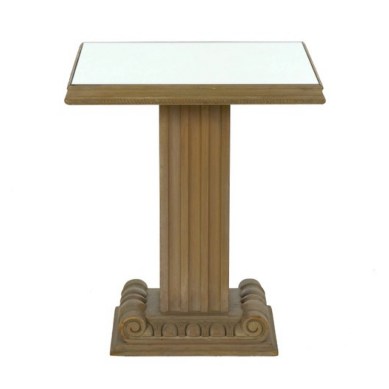

In [58]:
img_path = "/home/taiaburrahman/dataset_manager_pro/data/processed/v9/gen_ai_detector_dataset/human/09751b3d-fb3a-4ccd-b835-1f2210d70fa9.jpg"
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()